i want you to make me 5 histograms of the responses to the first 5 problems so that should be the number of people who responde 1,2,3,4 or not at all use algebra_tast_1_2.csv

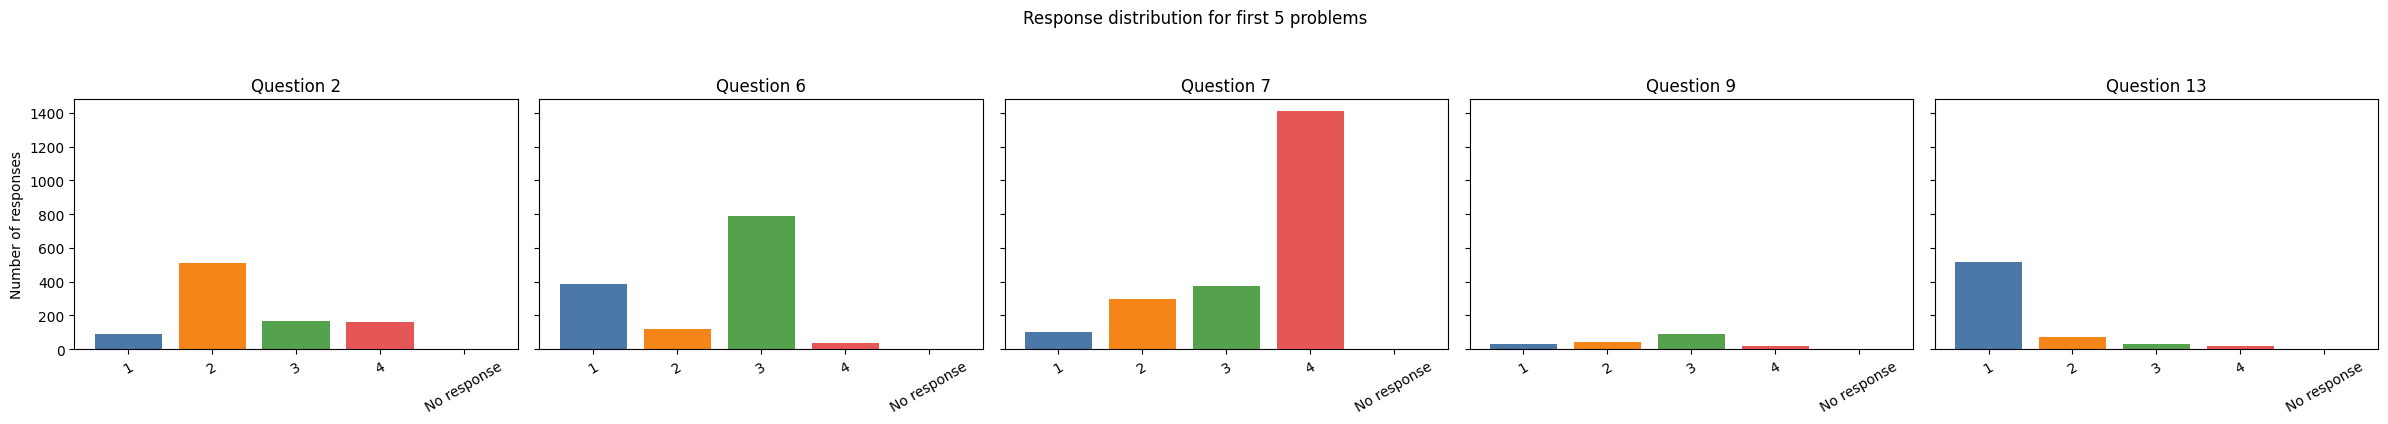

,question_id,1,2,3,4,No response,total
0,2,90,508,168,163,0,929
1,6,384,121,786,38,0,1329
2,7,102,296,372,1409,0,2179
3,9,28,42,91,16,0,177
4,13,518,74,31,19,0,642


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data (using the existing file in your workspace)
df = pd.read_csv("../data/algebra_task_1_2.csv")

# First 5 problems by question_id (sorted for consistency)
first_5_questions = sorted(df["question_id"].dropna().unique())[:5]

# Categories requested
categories = ["1", "2", "3", "4", "No response"]

fig, axes = plt.subplots(1, 5, figsize=(24, 4), sharey=True)

for ax, qid in zip(axes, first_5_questions):
    q_df = df[df["question_id"] == qid]

    # Normalize answers to strings for easy counting, keep missing as NaN
    answers = q_df["answer"].astype("string")
    no_response = ((answers.isna()) | (answers.str.strip() == "")).sum()

    counts = {
        "1": (answers == "1").sum(),
        "2": (answers == "2").sum(),
        "3": (answers == "3").sum(),
        "4": (answers == "4").sum(),
        "No response": no_response,
    }

    ax.bar(
        categories,
        [counts[c] for c in categories],
        color=["#4c78a8", "#f58518", "#54a24b", "#e45756", "#9d9d9d"],
    )
    ax.set_title(f"Question {qid}")
    ax.tick_params(axis="x", rotation=30)

axes[0].set_ylabel("Number of responses")
fig.suptitle("Response distribution for first 5 problems", y=1.05)
plt.tight_layout()
plt.show()

# Optional: print exact counts as a table
summary = []
for qid in first_5_questions:
    q_df = df[df["question_id"] == qid]
    answers = q_df["answer"].astype("string")
    no_response = ((answers.isna()) | (answers.str.strip() == "")).sum()
    summary.append({
        "question_id": qid,
        "1": (answers == "1").sum(),
        "2": (answers == "2").sum(),
        "3": (answers == "3").sum(),
        "4": (answers == "4").sum(),
        "No response": no_response,
        "total": (answers == "1").sum()+(answers == "2").sum()+(answers == "3").sum()+(answers == "4").sum()+no_response
    })

pd.DataFrame(summary)